In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.features.feature_engineer.apm_features import apm_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s22 = pd.read_csv('data/raw/season_stats/S22.csv').sort_values(by='GAME_DATE')
p22 = pd.read_csv('data/raw/playoff_stats/P22.csv').sort_values(by='GAME_DATE')
s22 = pd.concat([s22, p22])

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
p23 = pd.read_csv('data/raw/playoff_stats/P23.csv').sort_values(by='GAME_DATE')
s23 = pd.concat([s23, p23])

s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
p24 = pd.read_csv('data/raw/playoff_stats/P24.csv').sort_values(by='GAME_DATE')
s24 = pd.concat([s24, p24])

s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
p25 = pd.read_csv('data/raw/playoff_stats/P25.csv').sort_values(by='GAME_DATE')
s25 = pd.concat([s25, p25])

s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
p26 = pd.read_csv('data/raw/playoff_stats/P26.csv').sort_values(by='GAME_DATE')
s26 = pd.concat([s26, p26])
s26.sample(10)

,Unnamed: 0,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,START_POSITION,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,IS_PLAYOFF,POS,AGE,TEAM_SPREAD,GAME_TOTAL,STARTING,PTS_PER_MIN,AST_PER_MIN,REB_PER_MIN,IS_HOME,POSITION_ENCODED,name
24849,24808,2025-26,1630224,Jalen Green,Jalen,1610612756,PHX,Phoenix Suns,22501114,2026-04-02,PHX @ CHA,L,34.265000,10,19,0.526,3,6,0.500,2,2,1.000,1,3,4,7,3,2,1,2,1,2,25,-11,46.3,0,0,45.0,1,34:16,1,118.7,118.3,118.3,129.4,137.7,137.7,-10.7,-19.4,-19.4,0.292,2.33,23.3,0.029,0.086,0.058,10.0,10.0,0.605,0.629,0.284,0.291,100.97,98.06,81.72,98.06,0.149,71,10.0,19.0,F,4.56,2.79,3,5,8,60,1,0,35,7,10,0.700,3,9,0.333,0,0,0.000,42,91,0.462,16,39,0.410,7,10,0.700,9,22,31,22,12.0,4,5,4,21,19,107,-20.0,108.7,112.6,125.0,132.3,-16.3,-19.7,0.524,1.83,16.9,0.255,0.565,0.402,0.126,0.549,0.561,100.0,95.50,79.58,95,0.380,1610612766,CHA,Charlotte Hornets,48,93,0.516,18,49,0.367,13,15,0.867,11,36,47,27,13.0,7,4,5,19,21,127,20.0,125.0,132.3,108.7,112.6,16.3,19.7,0.563,2.08,19.1,0.435,0.745,0.598,0.135,0.613,0.638,100.0,95.50,79.58,96,0.620,0,SG,23.0,5.5,227.5,1,0.729607,0.204290,0.116737,0,4,NaN
18237,18288,2025-26,1631109,Mark Williams,Mark,1610612756,PHX,Phoenix Suns,22500811,2026-02-21,PHX vs. ORL,W,28.450000,4,10,0.400,0,0,0.000,1,1,1.000,2,7,9,1,1,0,0,4,3,4,9,-8,20.3,0,0,19.0,1,28:27,1,77.1,80.4,80.4,93.8,100.0,100.0,-16.7,-19.6,-19.6,0.077,1.00,8.3,0.048,0.233,0.125,8.3,8.0,0.400,0.431,0.162,0.172,96.94,91.95,76.63,91.95,0.111,56,4.0,10.0,C,4.25,2.15,9,12,20,36,0,0,23,3,9,0.333,1,1,1.000,3,6,0.500,40,117,0.342,16,55,0.291,17,24,0.708,22,43,65,20,9.0,11,4,15,20,21,113,3.0,98.6,101.8,97.9,102.8,0.7,-1.0,0.500,2.22,12.7,0.363,0.759,0.529,0.081,0.410,0.443,93.9,90.21,75.17,111,0.466,1610612753,ORL,Orlando Magic,42,98,0.429,10,39,0.256,16,19,0.842,10,43,53,24,16.0,6,15,4,21,20,110,-3.0,97.9,102.8,98.6,101.8,-0.7,1.0,0.571,1.50,16.6,0.241,0.638,0.471,0.150,0.480,0.517,93.9,90.21,75.17,107,0.534,0,C,24.0,-3.0,218.0,1,0.316344,0.035149,0.316344,1,0,NaN
5722,5612,2025-26,1628378,Donovan Mitchell,Donovan,1610612739,CLE,Cleveland Cavaliers,22500284,2025-11-24,CLE @ TOR,L,33.766667,6,20,0.300,3,12,0.250,2,2,1.000,0,1,1,8,2,1,0,0,0,4,17,-22,31.2,0,0,31.0,1,33:46,1,96.0,94.4,94.4,123.6,125.0,125.0,-27.6,-30.6,-30.6,0.444,4.00,25.8,0.000,0.037,0.016,6.5,6.5,0.375,0.407,0.299,0.306,102.12,102.35,85.29,102.35,0.068,72,6.0,20.0,G,4.14,2.17,0,3,3,76,2,1,48,1,4,0.250,5,16

In [4]:
res = []
for df in [s22, s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)
    df['STARTING'] = df['START_POSITION'].notna().astype(int)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["AST_PER_MIN"] = df["AST"] / df["MIN"].replace(0, np.nan)
    df['TCHS_PER_MIN'] = df['TCHS'] / df['MIN'].replace(0, np.nan)
    df["TOV_PER_MIN"] = df["TOV"] / df["MIN"].replace(0, np.nan)
    df['SAST_PER_MIN'] = df['SAST'] / df['MIN'].replace(0, np.nan)
    df['FTAST_PER_MIN'] = df['FTAST'] / df['MIN'].replace(0, np.nan)
    df['PASS_PER_MIN'] = df['PASS'] / df['MIN'].replace(0, np.nan)
    df['POSS_PER_MIN'] = df['POSS'] / df['MIN'].replace(0, np.nan)
    df = apm_features(df)

    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_AST_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['AST_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_TOV_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['TOV_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))

    
    df['MEDIAN_AST_PER_MIN_L10'] = (df.groupby('PLAYER_ID')['AST_PER_MIN'].transform(lambda x: x.shift(1).rolling(10).median().round(2)))
    df['AST_PER_MIN_DEVIATION'] = df['AST_PER_MIN_lag1'] - df['AST_PER_MIN_roll10']
    df['APM_TREND'] = df['AST_PER_MIN_5_ewm'] - df['AST_PER_MIN_season_avg']
    df['PASS_TREND'] = df['PASS_PER_MIN_5_ewm'] - df['PASS_PER_MIN_season_avg']
    df["AST_PER_MIN_STD_SEASON"] = df.groupby("PLAYER_ID", group_keys=False)["AST_PER_MIN"].transform(
    lambda x: x.shift(1).expanding(min_periods=2).std())

    le = LabelEncoder()
    df['POSITION_ENCODED'] = le.fit_transform(df['POS'])

    df['MIN_REG'] = df['MIN'].clip(upper=48)
    df = df[(df['MIN_REG'] >= 15) | (df['STARTING'] == 1)]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.sample()

(107625, 371)


,Unnamed: 0.2,Unnamed: 0.1,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,START_POSITION,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,IS_PLAYOFF,POS,AGE,TEAM_SPREAD_ODDS,GAME_TOTAL_ODDS,TEAM_SPREAD,GAME_TOTAL,STARTING,PTS_PER_MIN,AST_PER_MIN,REB_PER_MIN,IS_HOME,POSITION_ENCODED,TCHS_PER_MIN,TOV_PER_MIN,SAST_PER_MIN,FTAST_PER_MIN,PASS_PER_MIN,POSS_PER_MIN,MIN_roll3,PTS_roll3,USG_PCT_roll3,PLUS_MINUS_roll3,POSS_roll3,AST_TO_roll3,AST_roll3,AST_PCT_roll3,AST_RATIO_roll3,TOV_roll3,AST_PER_MIN_roll3,TOV_PER_MIN_roll3,POSS_PER_MIN_roll3,SAST_PER_MIN_roll3,FTAST_PER_MIN_roll3,PASS_PER_MIN_roll3,TCHS_PER_MIN_roll3,MIN_roll5,PTS_roll5,USG_PCT_roll5,PLUS_MINUS_roll5,POSS_roll5,AST_TO_roll5,AST_roll5,AST_PCT_roll5,AST_RATIO_roll5,TOV_roll5,AST_PER_MIN_roll5,TOV_PER_MIN_roll5,POSS_PER_MIN_roll5,SAST_PER_MIN_roll5,FTAST_PER_MIN_roll5,PASS_PER_MIN_roll5,TCHS_PER_MIN_roll5,MIN_roll10,PTS_roll10,USG_PCT_roll10,PLUS_MINUS_roll10,POSS_roll10,AST_TO_roll10,AST_roll10,AST_PCT_roll10,AST_RATIO_roll10,TOV_roll10,AST_PER_MIN_roll10,TOV_PER_MIN_roll10,POSS_PER_MIN_roll10,SAST_PER_MIN_roll10,FTAST_PER_MIN_roll10,PASS_PER_MIN_roll10,TCHS_PER_MIN_roll10,AST_PER_MIN_3_ewm,AST_3_ewm,TOV_PER_MIN_3_ewm,TOV_3_ewm,POSS_PER_MIN_3_ewm,AST_PCT_3_ewm,AST_TO_3_ewm,MIN_3_ewm,USG_PCT_3_ewm,SAST_PER_MIN_3_ewm,FTAST_PER_MIN_3_ewm,PASS_PER_MIN_3_ewm,TCHS_PER_MIN_3_ewm,AST_PER_MIN_5_ewm,AST_5_ewm,TOV_PER_MIN_5_ewm,TOV_5_ewm,POSS_PER_MIN_5_ewm,AST_PCT_5_ewm,AST_TO_5_ewm,MIN_5_ewm,USG_PCT_5_ewm,SAST_PER_MIN_5_ewm,FTAST_PER_MIN_5_ewm,PASS_PER_MIN_5_ewm,TCHS_PER_MIN_5_ewm,AST_PER_MIN_10_ewm,AST_10_ewm,TOV_PER_MIN_10_ewm,TOV_10_ewm,POSS_PER_MIN_10_ewm,AST_PCT_10_ewm,AST_TO_10_ewm,MIN_10_ewm,USG_PCT_10_ewm,SAST_PER_MIN_10_ewm,FTAST_PER_MIN_10_ewm,PASS_PER_MIN_10_ewm,TCHS_PER_MIN_10_ewm,AST_PER_MIN_lag1,AST_lag1,TOV_PER_MIN_lag1,TOV_lag1,POSS_PER_MIN_lag1,SAST_PER_MIN_lag1,FTAST_PER_MIN_lag1,PASS_PER_MIN_lag1,TCHS_PER_MIN_lag1,AST_PER_MIN_lag2,AST_lag2,TOV_PER_MIN_lag2,TOV_lag2,POSS_PER_MIN_lag2,SAST_PER_MIN_lag2,FTAST_PER_MIN_lag2,PASS_PER_MIN_lag2,TCHS_PER_MIN_lag2,MIN_season_avg,AST_season_avg,USG_PCT_season_avg,POSS_season_avg,PF_season_avg,OFF_RATING_season_avg,AST_PER_MIN_season_avg,SAST_PER_MIN_season_avg,FTAST_PER_MIN_season_avg,PASS_PER_MIN_season_avg,TCHS_PER_MIN_season_avg,PTS_PER_MIN_roll5,NET_RATING_roll5,TS_PCT_roll5,TEAM_PACE_roll10,TEAM_AST_roll10,TEAM_NET_RATING_roll10,MIN_share_proxy,AST_share_proxy_ro

In [5]:
APM_FEATURES = [
    'AST_PER_MIN_season_avg',      # dominant baseline
    'TCHS_PER_MIN_10_ewm',         # touch volume
    'AST_PCT_10_ewm',              # assist rate rolling
    'PASS_PER_MIN_5_ewm',          # pass volume
    'OPP_TEAM_AST_ALLOWED',        # opponent context
    'POSITION_ENCODED',            # role type
    'TEAM_AST_PER_MIN_RANK_L10',   # relative playmaking role
    'FTAST_PER_MIN_season_avg',    # playmaking baseline
    'AST_PER_MIN_lag1',            # last game
    'FTAST_PER_MIN_10_ewm',        # free throw assist rolling
    'IS_PLAYOFF',
    'AST_PER_MIN_5_ewm',
    'AST_PER_MIN_DEVIATION',
    'APM_TREND',
    'PASS_TREND',
    'AST_PER_MIN_STD_SEASON'
]

In [5]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score

# ── 1. Base dataframe ─────────────────────────────────────────────────────────
ppm_df = (
    df[APM_FEATURES + ["AST_PER_MIN", "GAME_DATE"]]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

X = ppm_df[APM_FEATURES]
y = ppm_df["AST_PER_MIN"]

quantiles = [0.10, 0.50, 0.90]
#Best params: {'n_estimators': 1344, 'max_depth': 3, 'learning_rate': 0.0199208375412252, 'subsample': 0.6525095024077675, 'colsample_bytree': 0.7424913081435832, 'reg_alpha': 3.890568820995351, 'reg_lambda': 0.007402304793152013, 'min_child_weight': 10}
XGB_PARAMS = dict(
    objective          = "reg:quantileerror",
    n_estimators       = 1344,
    max_depth          = 3,
    learning_rate      = 0.0199208375412252,
    subsample          = 0.6525095024077675,
    colsample_bytree   = 0.7424913081435832,
    reg_alpha          = 3.890568820995351,
    reg_lambda         = 4.755281357016035,
    min_child_weight   = 10,
    n_jobs             = -1,
    random_state       = 42,
    early_stopping_rounds = 50,
)


def fit_quantile_models(X_train, y_train, X_val, y_val):
    """Train one XGB quantile model per quantile, return preds dict."""
    models = {}
    preds  = {}
    for q in quantiles:
        m = XGBRegressor(**XGB_PARAMS, quantile_alpha=q)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
        key        = f"q_{q:.2f}"
        models[key] = m
        preds[key]  = m.predict(X_val)
    return models, preds


def score_fold(actual, preds, models, fold_label):
    lower    = preds["q_0.10"]
    median   = preds["q_0.50"]
    upper    = preds["q_0.90"]
    coverage = np.mean((actual >= lower) & (actual <= upper))
    metrics  = {
        "fold":           fold_label,
        "n":              len(actual),
        "mae":            mean_absolute_error(actual, median),
        "r2":             r2_score(actual, median),
        "coverage_80pct": coverage,
        "best_iters":     {k: models[k].best_iteration for k in models},
    }
    print(f"{fold_label:30s} | MAE: {metrics['mae']:.3f} | "
          f"R²: {metrics['r2']:.3f} | "
          f"80% Coverage: {coverage:.1%}")
    return metrics


# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — TimeSeriesSplit (feature selection / hyperparameter tuning)
#
# Use this to compare models or features without data leakage.
# NOT your final performance estimate — train set grows each fold
# which inflates later folds.
# ════════════════════════════════════════════════════════════════════════════

print("── Phase 1: TimeSeriesSplit ─────────────────────────────────────")
print(f"Data shape: {X.shape}")
tscv        = TimeSeriesSplit(n_splits=5)
tscv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models, f"TSCV fold {fold+1}")
    tscv_results.append(metrics)

maes = [r["mae"] for r in tscv_results]
r2s  = [r["r2"]  for r in tscv_results]
covs = [r["coverage_80pct"] for r in tscv_results]
print(f"\nTimeSeriesSplit Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")


── Phase 1: TimeSeriesSplit ─────────────────────────────────────
Data shape: (126274, 12)
TSCV fold 1                    | MAE: 0.049 | R²: 0.405 | 80% Coverage: 79.1%
TSCV fold 2                    | MAE: 0.049 | R²: 0.428 | 80% Coverage: 79.7%
TSCV fold 3                    | MAE: 0.051 | R²: 0.390 | 80% Coverage: 79.6%
TSCV fold 4                    | MAE: 0.051 | R²: 0.376 | 80% Coverage: 79.3%
TSCV fold 5                    | MAE: 0.053 | R²: 0.373 | 80% Coverage: 79.5%

TimeSeriesSplit Summary
  MAE      : 0.051 ± 0.001
  R²       : 0.395  ± 0.020
  Coverage : 79.4% ± 0.2%  (target ~80%)


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Walk-Forward (final validation / production simulation)
#
# Fixed training window that slides forward — mimics how you'll
# actually retrain in production. Use these numbers to decide
# whether to trust the model with real money.
# ════════════════════════════════════════════════════════════════════════════

TRAIN_WINDOW = int(len(ppm_df) * 0.50)   # fixed window size (games)
STEP_SIZE    = int(len(ppm_df) * 0.10)   # retrain every N games
N_FOLDS      = 4

wf_results = []

for fold in range(N_FOLDS):
    train_start = fold * STEP_SIZE
    train_end   = train_start + TRAIN_WINDOW
    val_end     = train_end   + STEP_SIZE

    if val_end > len(ppm_df):
        break

    X_tr  = X.iloc[train_start:train_end]
    X_val = X.iloc[train_end:val_end]
    y_tr  = y.iloc[train_start:train_end]
    y_val = y.iloc[train_end:val_end]

    date_start = ppm_df["GAME_DATE"].iloc[train_start]
    date_end   = ppm_df["GAME_DATE"].iloc[train_end - 1]
    date_val   = ppm_df["GAME_DATE"].iloc[val_end - 1]

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    label   = f"WF fold {fold+1} ({date_end} → {date_val})"
    metrics = score_fold(y_val.values, preds, models, label)
    metrics.update({"train_start": date_start, "train_end": date_end, "val_end": date_val})
    wf_results.append(metrics)

maes = [r["mae"] for r in wf_results]
r2s  = [r["r2"]  for r in wf_results]
covs = [r["coverage_80pct"] for r in wf_results]
print(f"\nWalk-Forward Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")

# Drift check — is the model degrading over time?
print("\nMAE over folds (should be stable, not rising):")
for r in wf_results:
    bar = "█" * int(r["mae"] * 4)
    print(f"  {r['fold']:30s} {r['mae']:.3f}  {bar}")   

WF fold 1 (2023-05-14 00:00:00 → 2024-02-08 00:00:00) | MAE: 0.051 | R²: 0.392 | 80% Coverage: 79.0%
WF fold 2 (2024-02-08 00:00:00 → 2024-11-25 00:00:00) | MAE: 0.051 | R²: 0.385 | 80% Coverage: 79.3%
WF fold 3 (2024-11-25 00:00:00 → 2025-03-19 00:00:00) | MAE: 0.051 | R²: 0.387 | 80% Coverage: 79.3%
WF fold 4 (2025-03-19 00:00:00 → 2026-01-01 00:00:00) | MAE: 0.052 | R²: 0.375 | 80% Coverage: 79.2%

Walk-Forward Summary
  MAE      : 0.051 ± 0.000
  R²       : 0.385  ± 0.006
  Coverage : 79.2% ± 0.1%  (target ~80%)

MAE over folds (should be stable, not rising):
  WF fold 1 (2023-05-14 00:00:00 → 2024-02-08 00:00:00) 0.051  
  WF fold 2 (2024-02-08 00:00:00 → 2024-11-25 00:00:00) 0.051  
  WF fold 3 (2024-11-25 00:00:00 → 2025-03-19 00:00:00) 0.051  
  WF fold 4 (2025-03-19 00:00:00 → 2026-01-01 00:00:00) 0.052  


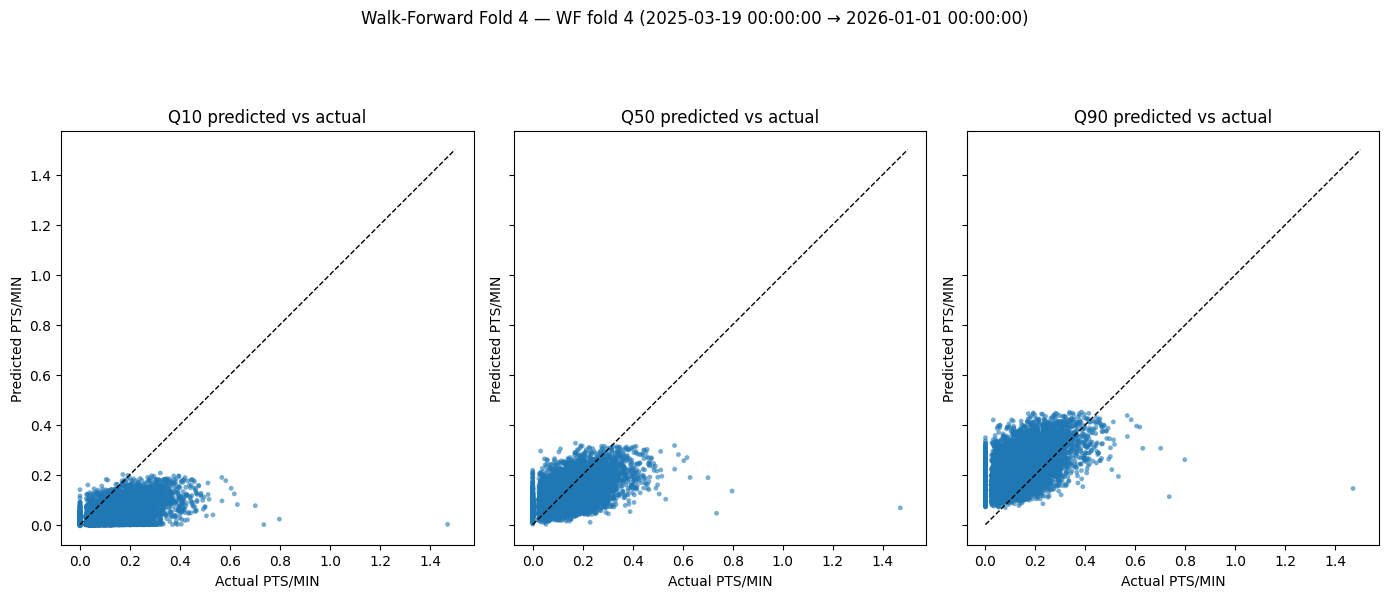

Coverage per quantile (should match quantile value):
  Q10: 11.1%  (target 10%, delta +1.1%)
  Q50: 50.9%  (target 50%, delta +0.9%)
  Q90: 90.3%  (target 90%, delta +0.3%)

80% interval width (Q10→Q90):
  mean : 0.17 min
  median: 0.16 min
  std  : 0.04 min


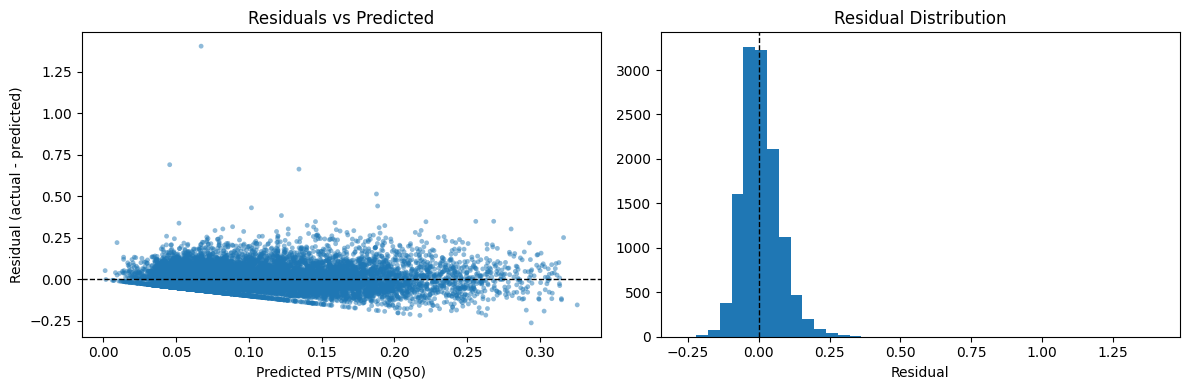


Residual summary:
  mean bias : +0.006 min  (close to 0 = unbiased)
  std       : 0.069 min


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ── pull from last walk-forward fold ─────────────────────────────────────────
last_fold   = wf_results[-1]
last_fold_n = last_fold["n"]

# re-identify the val slice from the last WF fold
fold        = N_FOLDS - 1
train_start = fold * STEP_SIZE
train_end   = train_start + TRAIN_WINDOW
val_end     = train_end + STEP_SIZE

X_val_last  = X.iloc[train_end:val_end]
y_val_last  = y.iloc[train_end:val_end]

# re-run predictions from the stored models (retrain if you didn't store them)
# if you stored models per fold, swap this block out
models_last, preds_last = fit_quantile_models(
    X.iloc[train_start:train_end],
    y.iloc[train_start:train_end],
    X_val_last,
    y_val_last,
)

y_true   = y_val_last.values
pred_low  = preds_last["q_0.10"]
pred_mid  = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]

preds = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

# ── predicted vs actual scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual PTS/MIN")
    ax.set_ylabel("Predicted PTS/MIN")
    ax.set_aspect("equal", adjustable="box")

plt.suptitle(f"Walk-Forward Fold {N_FOLDS} — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

# ── coverage per quantile ─────────────────────────────────────────────────────
print("Coverage per quantile (should match quantile value):")
for name, y_pred in preds.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta    = coverage - q_target
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})")

# ── interval width distribution ───────────────────────────────────────────────
interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean : {interval_width.mean():.2f} min")
print(f"  median: {np.median(interval_width):.2f} min")
print(f"  std  : {interval_width.std():.2f} min")

# ── residual plot (median only) ───────────────────────────────────────────────
residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted PTS/MIN (Q50)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.3f} min  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.3f} min")


── q_0.10 ──


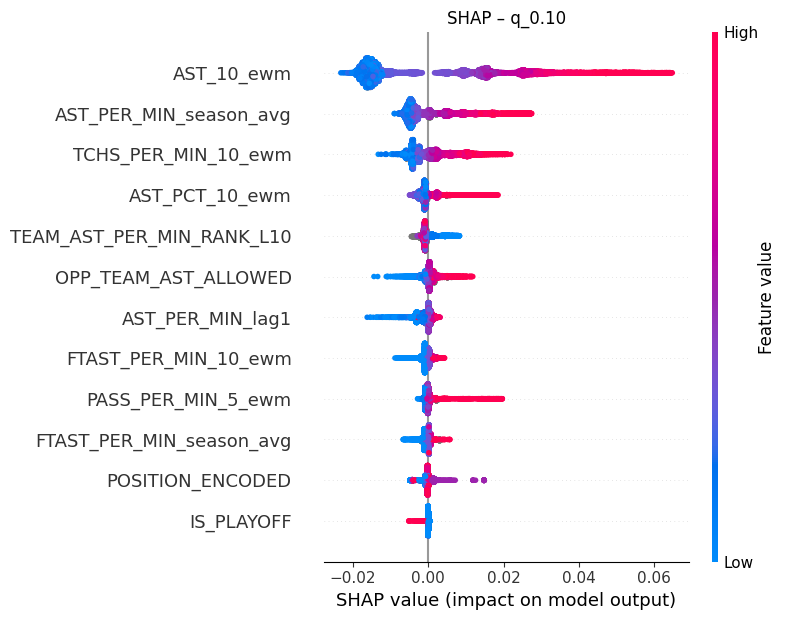


── q_0.50 ──


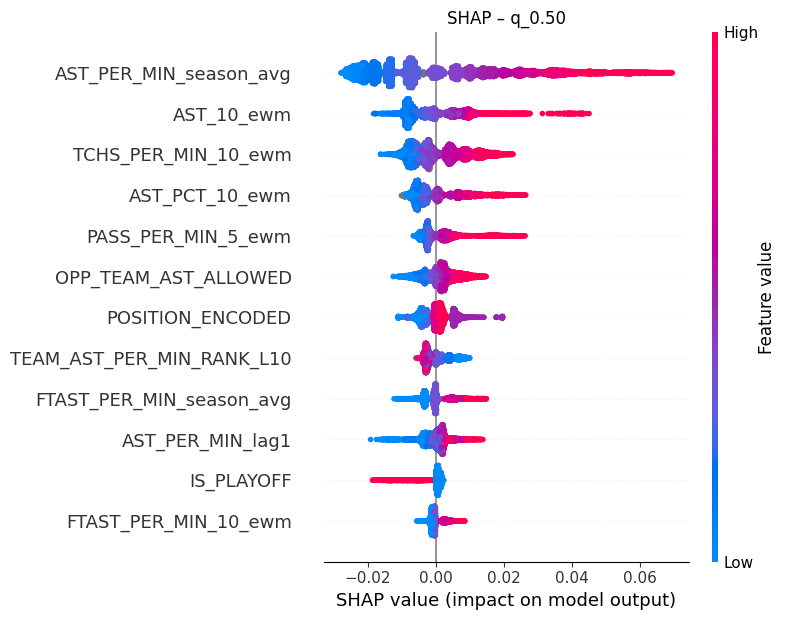


── q_0.90 ──


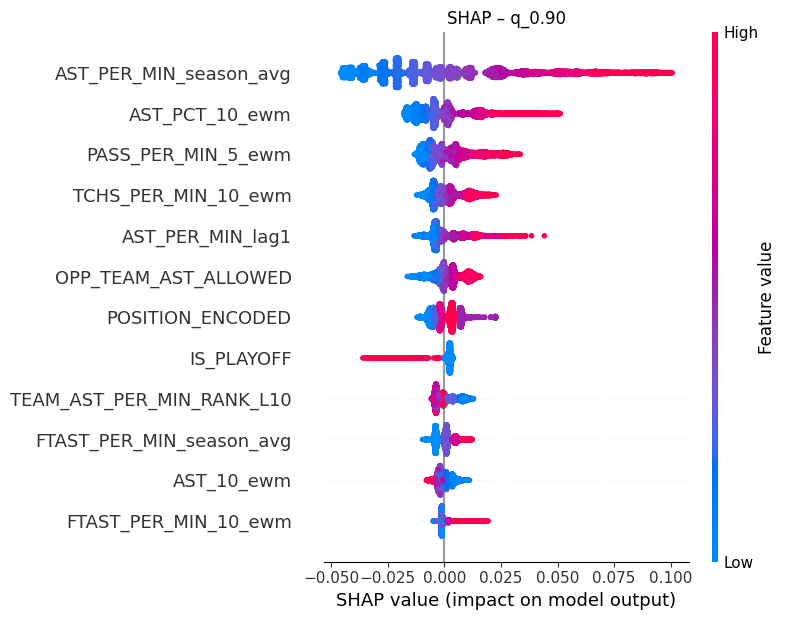

In [8]:
import shap

for q_key, model in models_last.items():
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X_val_last)

    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP – {q_key}")
    plt.tight_layout()
    plt.show()

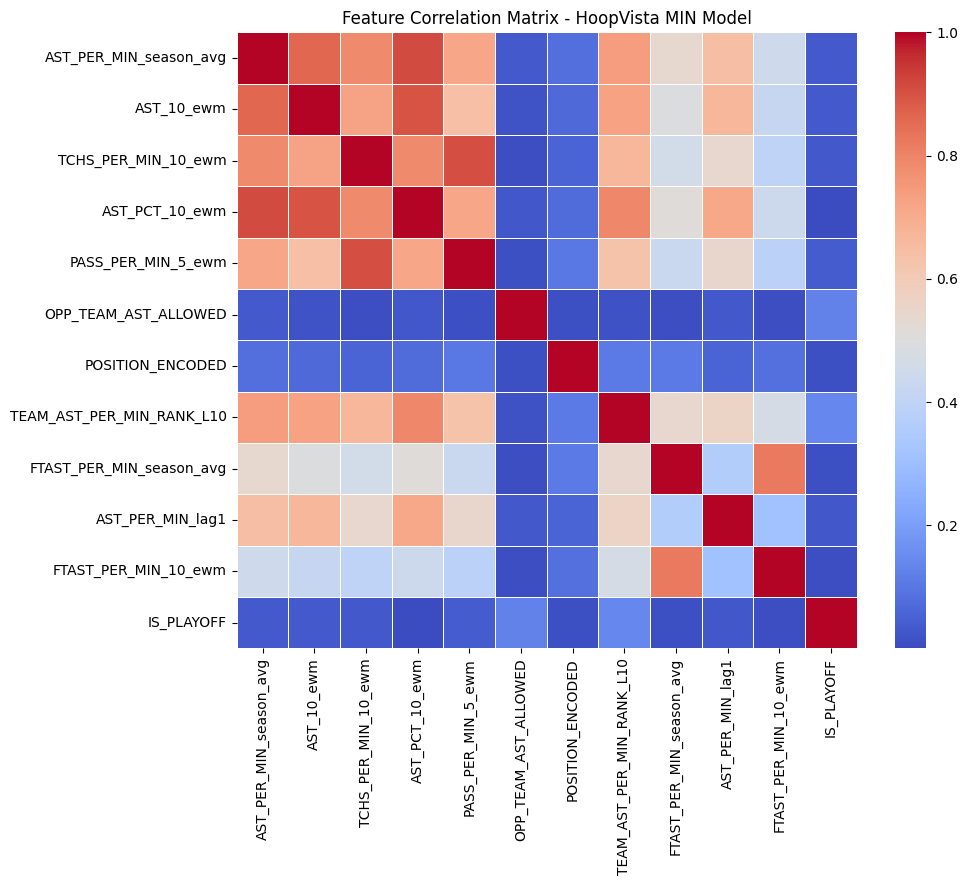

--- High Correlation Report (Threshold > 0.95) ---
No features exceed the correlation threshold.


[]

In [9]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, APM_FEATURES)
correlated_features

In [10]:
import joblib
from pathlib import Path

# save_dir = Path("models")
# save_dir.mkdir(exist_ok=True)

# ── save ──────────────────────────────────────────────────────────────────────
bundle = {
    "quantile_models": models_last,       # from final WF fold
    "feature_names":   APM_FEATURES,
    "fold_metrics":    wf_results,        # full validation history
    "train_end":       last_fold["train_end"],
    "val_end":         last_fold["val_end"],
}

save_path = f"apm_quantile_xgb_{last_fold['val_end'].date()}.joblib"
joblib.dump(bundle, save_path)
print(f"Saved to {save_path}")

# ── load ──────────────────────────────────────────────────────────────────────
bundle         = joblib.load(save_path)
models_loaded  = bundle["quantile_models"]
feature_names  = bundle["feature_names"]

# sanity check — should match your walk-forward MAE
test_preds = models_loaded["q_0.50"].predict(X_val_last)
print(f"Loaded model MAE: {mean_absolute_error(y_val_last, test_preds):.3f}")
print(f"Trained on data up to: {bundle['train_end']}")
print(f"Validated on data up to: {bundle['val_end']}")

# ── inference (new data) ──────────────────────────────────────────────────────
def predict_ppm(player_features: pd.DataFrame) -> pd.DataFrame:
    """
    Pass in a dataframe with the same columns as MIN_FEATURES.
    Returns Q10/Q50/Q90 predictions per row.
    """
    assert list(player_features.columns) == feature_names, \
        f"Feature mismatch — expected {feature_names}"

    return pd.DataFrame({
        "q10": models_loaded["q_0.10"].predict(player_features),
        "q50": models_loaded["q_0.50"].predict(player_features),
        "q90": models_loaded["q_0.90"].predict(player_features),
    })

Saved to apm_quantile_xgb_2026-01-01.joblib
Loaded model MAE: 0.052
Trained on data up to: 2025-03-19 00:00:00
Validated on data up to: 2026-01-01 00:00:00
